# Footfall: Data Cleaning, Exploratory Data Analysis and Distribution

In [280]:
pip install matplotlib geopandas numpy scipy folium

Note: you may need to restart the kernel to use updated packages.


In [281]:
#Import packages
import pandas as pd
import seaborn as sns
import matplotlib
import matplotlib.pyplot as plt
import geopandas as gpd
import numpy as np

The data is loaded and cleaned.

In [282]:
#Load mixed footfall data
footfall_mix = pd.read_csv(r"C:\Users\qxnq723\Desktop\Project 1\HUQ Data\footfall-mix.csv")
footfall_mix.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2993 entries, 0 to 2992
Data columns (total 6 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   datestamp                          2993 non-null   object 
 1   centre_name                        2993 non-null   object 
 2   purchasing_power_quantile          2993 non-null   int64  
 3   estimated_actual_footfall          2985 non-null   float64
 4   estimated_actual_footfall_rolling  2993 non-null   int64  
 5   source                             2993 non-null   object 
dtypes: float64(1), int64(2), object(3)
memory usage: 140.4+ KB


In [283]:
#Load footfall data for the 'Met Office - Bradford' area
footfall_MetOf = pd.read_csv(r"C:\Users\qxnq723\Desktop\Project 1\HUQ Data\footfall-MetOffice.csv")
footfall_MetOf.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2470 entries, 0 to 2469
Data columns (total 8 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   datestamp                          2470 non-null   object 
 1   centre_name                        2470 non-null   object 
 2   purchasing_power_quantile          2470 non-null   int64  
 3   estimated_actual_footfall          2306 non-null   float64
 4   estimated_actual_footfall_rolling  2470 non-null   int64  
 5   indexed_signal                     0 non-null      float64
 6   indexed_signal_rolling             0 non-null      float64
 7   source                             2470 non-null   object 
dtypes: float64(3), int64(2), object(3)
memory usage: 154.5+ KB


In [284]:
#Drop empty columns
footfall_MetOf = footfall_MetOf.drop(columns=['indexed_signal', 'indexed_signal_rolling'])

In [285]:
#Check area names and counts
footfall_mix['centre_name'].value_counts()

centre_name
Bradford BID                   2497
Bradford - City Centre           83
Bradford - Penistone Hill        83
Cliffe Castle Park - BD20 6      83
Lister Park - BD9 4              83
Wibsey Park - BD6 3              83
Bowling Park - BD4 7             81
Name: count, dtype: int64

In [286]:
#Check area names and counts
footfall_MetOf['centre_name'].value_counts()

centre_name
Met Office - Bradford    2470
Name: count, dtype: int64

In [287]:
#Check start and end dates of dataset
footfall_mix['datestamp'].unique()

array(['2018-12-01', '2019-01-01', '2019-01-02', ..., '2025-11-08',
       '2025-11-09', '2025-11-10'], dtype=object)

In [288]:
#Check start and end dates of dataset
footfall_MetOf['datestamp'].unique()

array(['2019-01-01', '2019-01-02', '2019-01-03', ..., '2025-10-04',
       '2025-10-05', '2025-10-06'], dtype=object)

Here only the 'Bradford BID' and the 'Met Office - Bradford' areas have daily data, the rest are monthly footfall counts. Here only the daily data is kept for modelling, the monthly data will be used in other model if time permits.

In [289]:
#Keep only areas with daily data: Bradford BID and Met Office areas
footfall_BID = footfall_mix[footfall_mix['centre_name']== 'Bradford BID']

#And join both together
footfall = pd.concat([footfall_BID, footfall_MetOf], ignore_index= True)
footfall.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4967 entries, 0 to 4966
Data columns (total 6 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   datestamp                          4967 non-null   object 
 1   centre_name                        4967 non-null   object 
 2   purchasing_power_quantile          4967 non-null   int64  
 3   estimated_actual_footfall          4795 non-null   float64
 4   estimated_actual_footfall_rolling  4967 non-null   int64  
 5   source                             4967 non-null   object 
dtypes: float64(1), int64(2), object(3)
memory usage: 233.0+ KB


In [290]:
#Convert datestamp to datetime
footfall['datestamp'] = pd.to_datetime(footfall['datestamp'])

In [291]:
#Check for 0s
print(footfall.isnull().sum())

datestamp                              0
centre_name                            0
purchasing_power_quantile              0
estimated_actual_footfall            172
estimated_actual_footfall_rolling      0
source                                 0
dtype: int64


In [292]:
#Check for duplicates
print(footfall.duplicated().sum())

0


In [293]:
#Check missing data in 'estimated actual footfall'
footfall['estimated_actual_footfall'].isna().value_counts()
#have _ days with missing footfall information

estimated_actual_footfall
False    4795
True      172
Name: count, dtype: int64

In [294]:
#Check missing data in 'estimated actual footfall rolling'
footfall['estimated_actual_footfall_rolling'].isna().value_counts()
#have _ missing data points

estimated_actual_footfall_rolling
False    4967
Name: count, dtype: int64

In [295]:
footfall.head()

,datestamp,centre_name,purchasing_power_quantile,estimated_actual_footfall,estimated_actual_footfall_rolling,source
0,2019-01-01,Bradford BID,0,88835.0,90080,huq-bradford-city-of-culture/bradford/daily/fo...
1,2019-01-02,Bradford BID,0,208076.0,106475,huq-bradford-city-of-culture/bradford/daily/fo...
2,2019-01-03,Bradford BID,0,91964.0,109110,huq-bradford-city-of-culture/bradford/daily/fo...
3,2019-01-04,Bradford BID,0,29687.0,104225,huq-bradford-city-of-culture/bradford/daily/fo...
4,2019-01-05,Bradford BID,0,95077.0,97116,huq-bradford-city-of-culture/bradford/daily/fo...


In [296]:
#Drop unneeded columns
footfall = footfall.drop(columns=['purchasing_power_quantile', 'source'])

In [297]:
#Check basic stats
footfall.describe()

,datestamp,estimated_actual_footfall,estimated_actual_footfall_rolling
count,4967,4.795000e+03,4.967000e+03
mean,2022-05-27 07:02:59.021542400,3.574835e+05,3.810977e+05
min,2019-01-01 00:00:00,8.004000e+03,1.740500e+04
25%,2020-09-12 12:00:00,7.349000e+04,7.773450e+04
50%,2022-05-26 00:00:00,1.439370e+05,1.578480e+05
75%,2024-02-08 12:00:00,6.293520e+05,6.346105e+05
max,2025-11-10 00:00:00,1.150276e+06,1.252827e+06
std,NaN,2.996401e+05,3.209679e+05


In [298]:
#Check basic stats by area
footfall.groupby('centre_name').describe()

datestamp                                 \
                          count                           mean   
centre_name                                                      
Bradford BID               2497  2022-06-03 23:12:42.675210240   
Met Office - Bradford      2470  2022-05-19 12:52:28.178137600   

                                                                 \
                                       min                  25%   
centre_name                                                       
Bradford BID           2019-01-01 00:00:00  2020-09-16 00:00:00   
Met Office - Bradford  2019-01-01 00:00:00  2020-09-09 06:00:00   

                                                                 \
                                       50%                  75%   
centre_name                                                       
Bradford BID           2022-06-02 00:00:00  2024-02-21 00:00:00   
Met Office - Bradford  2022-05-19 12:00:00  2024-01-26 18:00:00   

                                                estimated_actual_footfall  \
                                       max  std                     count   
centre_name                                                                 
Bradford BID           2025-11-10 00:00:00  NaN                    2489.0   
Met Office - Bradford  2025-10-06 00:00:00  NaN                    2306.0   

                                      ...                            \
                                mean  ...        max            std   
centre_name                           ...                             
Bradford BID            78299.592607  ...   244074.0   33793.508127   
Met Office - Bradford  658822.941457  ...  1150276.0  102432.299734   

                      estimated_actual_footfall_rolling                 \
                                                  count           mean   
centre_name                                                              
Bradford BID                                     2497.0   78496.543052   
Met Office - Bradford                            2470.0  687006.740891   

                                                                           \
                            min       25%       50%        75%        max   
centre_name                                                                 
Bradford BID            17405.0   58422.0   77829.0   97927.00   171279.0   
Met Office - Bradford  477462.0  599360.0  634978.0  723956.75  1252827.0   

                                      
                                 std  
centre_name                           
Bradford BID            28309.358800  
Met Office - Bradford  142037.777479  

[2 rows x 24 columns]

## Outlier removal

Dates with very high or very low footfall counts are excluded using the Median Average Distance technique.

In [ ]:
def doubleMADsfromMedian(y,thresh=3.5):
    """Find outliers using the Median Average Distance.
    
    VALUE: return a list of true/false denoting whether the element in y is an outlier or not
    
    PARAMETERS:
      - y is a pandas Series, or something like that.
    
    warning: this function does not check for NAs
    nor does it address issues when 
    more than 50% of your data have identical values
    """
    # Calculate the upper and lower limits
    m = np.median(y) # The median
    abs_dev = np.abs(y - m) # The absolute difference between each y and the median
    # The upper and lower limits are the median of the difference
    # of each data point from the median of the data
    left_mad = np.median(abs_dev[y <= m]) # The left limit (median of lower half)
    right_mad = np.median(abs_dev[y >= m]) # The right limit (median of upper half)
    
    # Now create an array where each value has left_mad if it is in the lower half of the data,
    # or right_mad if it is in the upper half
    y_mad = left_mad * np.ones(len(y)) # Initially every value is 'left_mad'
    y_mad[y > m] = right_mad # Now larger values are right_mad

    # Calculate the z scores for each element
    modified_z_score = 0.6745 * abs_dev / y_mad
    modified_z_score[y == m] = 0
    
    # Return boolean list showing whether each y is an outlier
    return modified_z_score > thresh

# Make a list of true/false for whether the footfall is an outlier
no_outliers = pd.DataFrame(doubleMADsfromMedian(original['InCount']))
no_outliers.columns = ['outlier'] # Rename the column to 'outlier'

# Join to the original footfall data to the list of outliers, then select a few useful columns
join = pd.concat([original, no_outliers], axis = 1)
join = pd.DataFrame(join, columns = ['Day_yr', 'outlier', 'InCount'])

# Choose just the outliers
outliers = join[join['outlier'] == True]
outliers_list = list(outliers['Day_yr']) # A list of the days that are outliers

# Now remove all outliers from the original data
df = original.loc[~original['Day_yr'].isin(outliers_list)]
df = df.reset_index(drop = True)

# Check that the lengths all make sense
assert(len(df) == len(original)-len(outliers_list))

print("I found {} outliers from {} days in total. Removing them leaves us with {} events".format(\
    len(outliers_list), len(join), len(df) ) )

Different variables columns are created to allow data exploration, extracting from the dates the year, the week of the year, the day of week, the month.

In [299]:
footfall['year']= footfall['datestamp'].dt.year
footfall['month'] = footfall['datestamp'].dt.month
footfall['weekday'] = footfall['datestamp'].dt.weekday
footfall['week_of_year'] = footfall['datestamp'].dt.isocalendar().week
footfall.head()

,datestamp,centre_name,estimated_actual_footfall,estimated_actual_footfall_rolling,year,month,weekday,week_of_year
0,2019-01-01,Bradford BID,88835.0,90080,2019,1,1,1
1,2019-01-02,Bradford BID,208076.0,106475,2019,1,2,1
2,2019-01-03,Bradford BID,91964.0,109110,2019,1,3,1
3,2019-01-04,Bradford BID,29687.0,104225,2019,1,4,1
4,2019-01-05,Bradford BID,95077.0,97116,2019,1,5,1


For machine learning model, cyclical encoding will be required, thus based on temporal variables previously created the following variables are created:
* day of week (sin and cos)
* week of year (sin and cos)
* month (sin and cos)

In [300]:
#Create function to create sin and cos columns of variables
def add_sin_and_cos_features(df, column_to_transform):
    df['Sin_{}'.format(column_to_transform)] = np.sin(2 * np.pi * df[column_to_transform] / max(df[column_to_transform])) 
    df['Cos_{}'.format(column_to_transform)] = np.cos(2 * np.pi * df[column_to_transform] / max(df[column_to_transform]))
    return df

In [301]:
#Apply function
footfall = add_sin_and_cos_features(footfall, 'weekday')
footfall = add_sin_and_cos_features(footfall, 'week_of_year')
footfall = add_sin_and_cos_features(footfall, 'month')
footfall.head()

,datestamp,centre_name,estimated_actual_footfall,estimated_actual_footfall_rolling,year,month,weekday,week_of_year,Sin_weekday,Cos_weekday,Sin_week_of_year,Cos_week_of_year,Sin_month,Cos_month
0,2019-01-01,Bradford BID,88835.0,90080,2019,1,1,1,8.660254e-01,0.5,0.118273,0.992981,0.5,0.866025
1,2019-01-02,Bradford BID,208076.0,106475,2019,1,2,1,8.660254e-01,-0.5,0.118273,0.992981,0.5,0.866025
2,2019-01-03,Bradford BID,91964.0,109110,2019,1,3,1,1.224647e-16,-1.0,0.118273,0.992981,0.5,0.866025
3,2019-01-04,Bradford BID,29687.0,104225,2019,1,4,1,-8.660254e-01,-0.5,0.118273,0.992981,0.5,0.866025
4,2019-01-05,Bradford BID,95077.0,97116,2019,1,5,1,-8.660254e-01,0.5,0.118273,0.992981,0.5,0.866025


The footfall counts in areas are merged to their asssociated area geometries.

In [302]:
#Load file with different geographical areas of Bradford
GDF_areas = gpd.read_file(r"C:\Users\qxnq723\Desktop\Project 1\HUQ Data\areas.geojson")
GDF_areas.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 8 entries, 0 to 7
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   centre_name  8 non-null      object  
 1   geometry     8 non-null      geometry
dtypes: geometry(1), object(1)
memory usage: 260.0+ bytes


In [303]:
#Print CRS
print(GDF_areas.crs)

EPSG:4326


In [304]:
GDF_areas['centre_name'].unique()

array(['Bowling Park - BD4 7', 'Wibsey Park - BD6 3',
       'Cliffe Castle Park - BD20 6', 'Lister Park - BD9 4',
       'Bradford BID', 'Met Office - Bradford', 'Bradford - City Centre',
       'Bradford - Penistone Hill'], dtype=object)

In [305]:
#Isolate the Bradford City Centre area
geo_cc = GDF_areas[GDF_areas['centre_name'] == 'Bradford - City Centre']
#Reproject to EPSG:27700 for UK
geo_cc = geo_cc.to_crs(epsg=27700)
#Find centroid in projected coordinates
CC_centroid = geo_cc.geometry.centroid

In [306]:
#Isolate the Met Office Bradford area
geo_brad = GDF_areas[GDF_areas['centre_name'] == 'Met Office - Bradford']

#Get the bounding box of the Bradford district polygon (used for weather scraping later on)
geo_brad = GDF_areas[GDF_areas['centre_name'] == 'Met Office - Bradford'].geometry
bbox = geo_brad.bounds
bbox
# minx = longitude west
# miny = latitude south
# maxx = longitude east
# maxy = latitude north

,minx,miny,maxx,maxy
5,-2.06125,53.72436,-1.64033,53.96317


In [307]:
#Merge the polygons and the footfall data
footfall = footfall.merge(GDF_areas[['centre_name', 'geometry']], on='centre_name')
footfall.head()

,datestamp,centre_name,estimated_actual_footfall,estimated_actual_footfall_rolling,year,month,weekday,week_of_year,Sin_weekday,Cos_weekday,Sin_week_of_year,Cos_week_of_year,Sin_month,Cos_month,geometry
0,2019-01-01,Bradford BID,88835.0,90080,2019,1,1,1,8.660254e-01,0.5,0.118273,0.992981,0.5,0.866025,"POLYGON ((-1.75387 53.78933, -1.75416 53.78928..."
1,2019-01-02,Bradford BID,208076.0,106475,2019,1,2,1,8.660254e-01,-0.5,0.118273,0.992981,0.5,0.866025,"POLYGON ((-1.75387 53.78933, -1.75416 53.78928..."
2,2019-01-03,Bradford BID,91964.0,109110,2019,1,3,1,1.224647e-16,-1.0,0.118273,0.992981,0.5,0.866025,"POLYGON ((-1.75387 53.78933, -1.75416 53.78928..."
3,2019-01-04,Bradford BID,29687.0,104225,2019,1,4,1,-8.660254e-01,-0.5,0.118273,0.992981,0.5,0.866025,"POLYGON ((-1.75387 53.78933, -1.75416 53.78928..."
4,2019-01-05,Bradford BID,95077.0,97116,2019,1,5,1,-8.660254e-01,0.5,0.118273,0.992981,0.5,0.866025,"POLYGON ((-1.75387 53.78933, -1.75416 53.78928..."


## Exploratory Data Analysis
Look at 'estimated_actual_footfall_rolling' distribution

c:\ProgramData\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning:

use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.

c:\ProgramData\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning:

use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.



<function matplotlib.pyplot.show(close=None, block=None)>

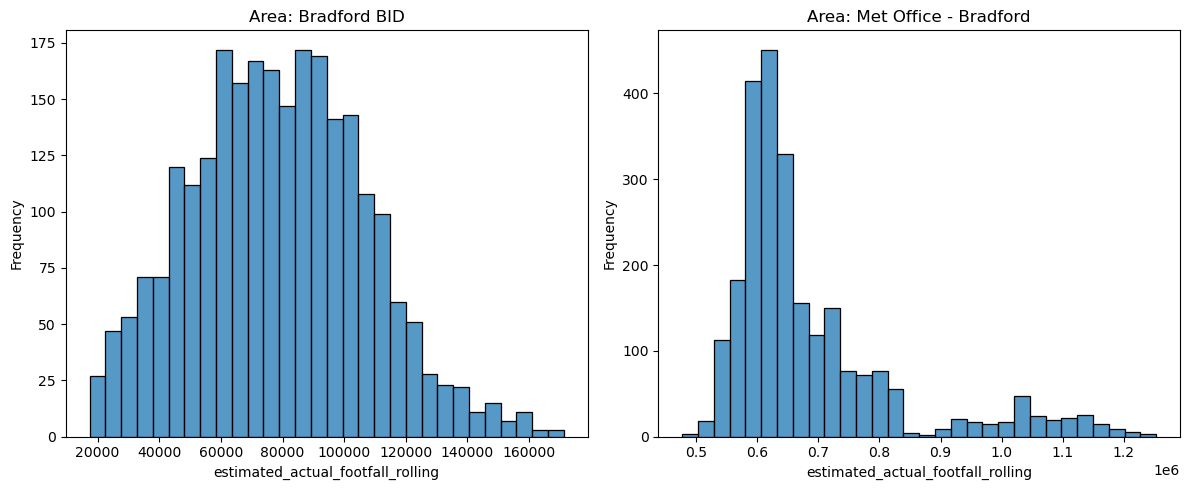

In [308]:
#Plot histograms of footfall counts for the 2 areas

areas = footfall['centre_name'].unique()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, area in zip(axes, areas):
    sns.histplot(
        data= footfall[footfall['centre_name']== area],
        x='estimated_actual_footfall_rolling',
        bins= 30,
        ax=ax,
    )
    ax.set_title(f'Area: {area}')
    ax.set_ylabel('Frequency')

plt.tight_layout()
plt.show

Plot variation over time metrics for the Bradford district area only

In [309]:
footfall_Met = footfall[footfall['centre_name'] == 'Met Office - Bradford']

In [310]:
timeMetrics = ['weekday','week_of_year', 'month', 'year']
weekday_map= {
    0: 'Mon',
    1: 'Tue',
    2: 'Wed',
    3: 'Thu',
    4: 'Fri',
    5: 'Sat',
    6: 'Sun'
}

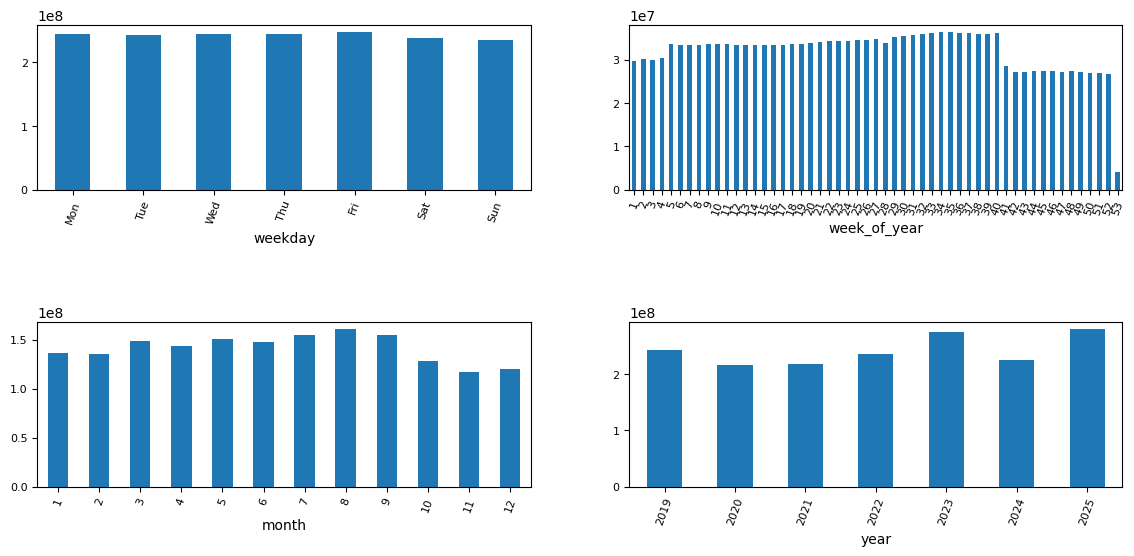

In [311]:
#Create summary plots over weekdays, week of year, months and years

fig, axs = plt.subplots(2, 2, figsize = (14,6))
plt.subplots_adjust(hspace=0.8)    
for i, ax in enumerate(axs.flat):
    metric = timeMetrics[i]
    if metric == 'weekday':
        weekday_series= (
            footfall_Met.groupby(['weekday'])['estimated_actual_footfall_rolling']
            .sum()
            .rename(index= weekday_map)
            .reindex(['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']))
        weekday_series.plot.bar(ax=ax, rot=70, fontsize = 8) 
    else:
        footfall_Met.groupby(metric)['estimated_actual_footfall_rolling'].sum().plot.bar(ax=ax, rot=70, fontsize = 8)   

Explore footfall time series (interactive plot which can be re-used in future dashboards)

In [312]:
#Plot interactive line graph of footfall throughout time,
#with button to select area of interest
# with hover option to check exact daily footfall count

import plotly.graph_objects as go

#Isolate regions and 
regions = footfall['centre_name'].unique()

#Create initial figure
fig_BradFF = go.Figure()
buttons = []
trace_count = 0

#Loop through each region
for i, region in enumerate(regions):
    df_region = footfall[footfall['centre_name'] == region].sort_values('datestamp')
    
    #Add traces for this variable
    fig_BradFF.add_scatter(
            x= df_region['datestamp'],
            y= df_region['estimated_actual_footfall_rolling'],
            mode='lines',
            name= region,
            line= dict(color='blue', width=2, dash='solid'),
            visible= (i==0), #only first is visible initially
            hovertemplate= '📅 %{x|%Y-%m-%d}<br> 👣Footfall: %{y:.1f}'
    )
    
    trace_count += 1

#Add buttons for dropdown menu
for i, region in enumerate(regions):
    visible_array = [False] * trace_count
    visible_array[i] = True
    buttons.append(dict(
        label=region,
        method='update',
        args=[{'visible': visible_array},
            {'title': f'Footfall Trend - {region}'}]
    ))

#Add dropdown and choose layout
fig_BradFF.update_layout(
    title= f'Footfall Trend - {regions[0]}',
    xaxis = dict(
        title= 'Date',
        showgrid= True,
        gridcolor='lightgrey',
        zeroline= False
    ),
    yaxis= dict(
        title='Footfall',
        showgrid= True,
        gridcolor='lightgrey',
        zeroline= False
    ),
    template= 'ggplot2',
    plot_bgcolor='rgba(0,0,0,0)',
    paper_bgcolor='rgba(0,0,0,0)',
    updatemenus=[dict(
        active=0,
        buttons=buttons,
        x= 0.1,
        y=1.2,
        xanchor= 'left',
        yanchor= 'top',
        direction='down',
        showactive= True
    )],
)

fig_BradFF.show()

The previous plot is modified by smoothing the trend line for more clearer visualisation.

In [313]:
#Smooth Spline Curve
#Plot interactive line graph of footfall throughout time
import plotly.express as px
from scipy.interpolate import make_interp_spline
import plotly.graph_objects as go

#Isolate regions
regions = footfall['centre_name'].unique()

#Create initial figure
fig_BradFF = go.Figure()
buttons = []

#Loop through each region
for i, region in enumerate(regions):
    df_region = footfall[footfall['centre_name'] == region].sort_values('datestamp')

    #Data prep
    x = df_region['datestamp']
    y = df_region['estimated_actual_footfall_rolling']

    #Create smoothed line with interpolation
    x_numeric = np.arange(len(x))
    X_Y_Spline = make_interp_spline(x_numeric, y)
    X_ = np.linspace(x_numeric.min(), x_numeric.max(), 500)
    Y_ = X_Y_Spline(X_)

    #Convert the dates back to show timeframe
    x_seconds = np.array([dt.timestamp() for dt in x])
    X_dates_seconds = np.interp(X_, x_numeric, x_seconds)
    X_dates = pd.to_datetime(X_dates_seconds, unit='s')
    
    #Add traces for this variable
    fig_BradFF.add_trace(
        go.Scatter(
            x= X_dates,
            y= Y_,
            mode='lines',
            line= dict(color='blue', width=2, dash='solid'),
            name= region,
            visible= (i==0), #only first is visible initially
            hovertemplate= '📅 %{x|%Y-%m-%d}<br> 👣Footfall: %{y:.1f}')
        )

#Add buttons for dropdown menu
for i, region in enumerate(regions):
    visible_array = [False] * len(regions)
    visible_array[i] = True
    buttons.append(dict(
        label=region,
        method='update',
        args=[{'visible': visible_array},
            {'title': f'Footfall Trend - {region}'}]
    ))

#Add dropdown and choose layout
fig_BradFF.update_layout(
    title= f'Footfall Trend - {regions[0]}',
    xaxis = dict(
        title= 'Date',
        showgrid= True,
        gridcolor='lightgrey',
        zeroline= False
    ),
    yaxis= dict(
        title='Footfall (Estimated Actual Rolling)',
        showgrid= True,
        gridcolor='lightgrey',
        zeroline= False
    ),
    template= 'ggplot2',
    plot_bgcolor='rgba(0,0,0,0)',
    paper_bgcolor='rgba(0,0,0,0)',
    updatemenus=[dict(
        active=0,
        buttons=buttons,
        x= 0.1,
        y=1.2,
        xanchor= 'left',
        yanchor= 'top',
        direction='down',
        showactive= True
    )],
)
    
fig_BradFF.show()

Comparing footfall seasonal trends in 2024 VS 2025. The following plots are also made interactive to be reused in dashboards.

In [314]:
# Plot seasonal footfall line graph,
# with months on the x axis
# allowing to compare footfall between 2024 and 2025
# with a button to select the area of interest

import plotly.express as px
import plotly.graph_objects as go

#Isolate the different regions
regions = footfall['centre_name'].unique()

#Create initial empty figure
fig_Brad24vs25 = go.Figure()
buttons = []

#Loop through each region
for r, region in enumerate(regions):
    df_region = footfall[footfall['centre_name'] == region].sort_values('datestamp')

    #Add 2024 and 2025 lines
    for year, color in zip([2024, 2025], ['blue', 'red']):
        df_year = df_region[df_region['datestamp'].dt.year == year].copy()
        if df_year.empty:
            continue

        x_doy = df_year['datestamp'].dt.dayofyear
        y = df_year['estimated_actual_footfall_rolling']

        #Add lines
        fig_Brad24vs25.add_scatter(
        x= x_doy,
        y= y,
        mode='lines',
        line= dict(color= color, width=2),
        name= f'{year}',
        visible=(r==0),
        customdata= df_year['datestamp'],
        hovertemplate= '📅 %{customdata|%Y-%m-%d}<br> 👣Footfall: %{y:.1f}'
    )

#Add 1 button per region
visibility = [False] * (2 * len(regions))
visibility[i*2] = True #2024 line
visibility[i*2+1] = True #2025 line

buttons.append(dict(
    label=region,
    method='update',
    args=[{'visible': visibility},
        {'title': f'Footfall Comparison (2024 vs 2025) - {region}'}]
))

#Add buttons for dropdown
for i, region in enumerate(regions):
        visible_array = [False] * (2* len(regions))
        visible_array[2*i] = True #2024 line
        visible_array[2*i +1] = True #2025 line
        buttons.append(dict(
            label= region,
            method='update',
            args=[{'visible': visible_array},
                 {'title': f'Footfall Comparison (2024 vs 2025) - {region}'}]
        ))

#Adapt layout with monthly ticks
month_starts = pd.date_range('2024-01-01', '2024-12-31', freq='MS')
month_labels = month_starts.strftime('%b')


#Add dropdown and choose layout
fig_Brad24vs25.update_layout(
    updatemenus=[dict(
        active=0,
        buttons=buttons,
        direction= 'down',
        x= 0.01,
        y=1.3,
        xanchor= 'left',
        yanchor= 'top',
        showactive= True
    )],
    hovermode= 'x unified',
    title= f'Footfall Comparison (2024 vs 2025) - {regions[0]}',
    xaxis=dict(
        title= 'Month',
        tickvals=[d.timetuple().tm_yday for d in month_starts],
        ticktext= month_labels,
        range=[1, 366],
        showgrid= True,
        gridcolor='lightgrey',
        zeroline= False
    ),
    yaxis= dict(
         title='Footfall (Estimated Actual Rolling)',
         showgrid= True,
         gridcolor='lightgrey',
         zeroline= False
    ),
    template= 'ggplot2',
    plot_bgcolor='rgba(0,0,0,0)',
    paper_bgcolor='rgba(0,0,0,0)',
)
    
fig_Brad24vs25.show()


Create interactive heatmap - calendar with buttons for years and area of interest.

**Warning**: Plot is not currently functional and will need to be revised.

In [315]:
#Data Preparation

#Isolate date string (YYYY-MM-DD)
footfall['date_str'] = footfall['datestamp'].dt.strftime('%Y-%m-%d')
#Create week index to avoid duplicates (change of year can be in same week)
footfall['week_monday'] = footfall['datestamp'] - pd.to_timedelta(footfall['datestamp'].dt.weekday, unit='d')
footfall['week_index'] = footfall['week_monday'].dt.strftime('%Y-%m-%d')

In [316]:
#Set-Up for daily heatmap for each year

#Set up yearly and region filtering
years = sorted(footfall['year'].unique())
regions = sorted(footfall['centre_name'].unique())

#Start with first year and first region to initialize figure
first_year = years[0]
first_region = regions[0]
data_init = footfall[(footfall['year'] == first_year) & (footfall['centre_name'] == first_region)]

#Create pivot table (2D matrix)
pivot = data_init.pivot(index='weekday', 
                        columns='week_index', 
                        values='estimated_actual_footfall_rolling')
pivot = pivot.reindex(index=range(7))
#Create other pivot table to have exact dates with hover tool
customdata = data_init.pivot(index='weekday', 
                             columns='week_index', 
                             values='date_str').values

#----------------------------------------------------------------------------------------------

#Create function -> to show month label only at first week of each month
def get_month_ticks(week_index):
    if len(week_index) == 0:
        return [], []
    
    dates= pd.to_datetime(week_index)
    months = dates.month

    #First week of month
    if len(months) == 1:
        first_w_month= np.array([True])
    else:
        first_w_month= np.r_[True, months[1:] != months[:-1]]

    tickvals= week_index[first_w_month]
    ticktext= dates[first_w_month].strftime('%b')

    return tickvals, ticktext

tickvals_init, ticktext_init = get_month_ticks(pivot.columns)

In [317]:
#Plotting daily heatmap

#Create initial heatmap
#Plot Interactive Daily Heatmap
fig_heatmap = px.imshow(
    pivot.values,
    labels= dict(x='Week of Year', y='Day of Week', color='Footfall'),
    x=pivot.columns,
    y=['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun'],
    color_continuous_scale='viridis_r',
    aspect='auto',
)

#Add hover with daily info
fig_heatmap.update_traces(
    hovertemplate= ' 📅Date:%{customdata}<br> 👣Footfall: %{z:,}',
    customdata= customdata
)

#Apply month ticks
fig_heatmap.update_xaxes(
    tickmode= 'array',
    tickvals= tickvals_init,
    ticktext=ticktext_init
)

#--------------------------------------------------------------------------------------------
#Create dropdown button for YEARS

year_buttons= []

for year in years:
    data_year = footfall[(footfall['year'] == year) & (footfall['centre_name']== first_region)]
    pivot_y = data_year.pivot(index='weekday', 
                              columns='week_index', 
                              values='estimated_actual_footfall_rolling').reindex(index=range(7))
    customdata_y = data_year.pivot(index='weekday', 
                                   columns='week_index', 
                                   values='date_str').values
    tickvals_y, ticktext_y = get_month_ticks(pivot_y.columns)

    year_buttons.append(dict(
        label=str(year), #text shown in drop down
        method='update', #update data instead of redrawing
        #z is new heatmap values, customdata is hover data
        args=[{'z': [pivot_y.values], 
               'customdata': [customdata_y], 
               'x':[pivot_y.columns]
               },
               {'xaxis': dict(
                   tickmode= 'array',
                   tickvals= tickvals_y,
                   ticktext= ticktext_y
               ),
              'title': f'Daily Footfall Heatmap - {year} - {first_region}'}]
    ))

#--------------------------------------------------------------------------------------------
#Create dropdown button for REGIONS

region_buttons= []

for region in regions:
    data_region = footfall[(footfall['year'] == first_year) & (footfall['centre_name']== region)]
    pivot_r = data_region.pivot(index='weekday', 
                                columns='week_index', 
                                values='estimated_actual_footfall_rolling').reindex(index=range(7))
    customdata_r = data_region.pivot(index='weekday', 
                                     columns='week_index', 
                                     values='date_str').values

    tickvals_r, ticktext_r = get_month_ticks(pivot_r.columns)

    region_buttons.append(dict(
        label= region, #text shown in drop down
        method='update', #update data instead of redrawing
        #z is new heatmap values, customdata is hover data
        args=[{'z': [pivot_r.values], 
               'customdata': [customdata_r],
               'x': [pivot_r.columns]
               },
               {'xaxis': dict(
                   tickmode= 'array',
                   tickvals= tickvals_r,
                   ticktext= ticktext_r
               ),
              'title': f'Daily Footfall Heatmap - {first_year} - {region}'}]
    ))

#--------------------------------------------------------------------------------------------
#Create plot layout
#Add both dropdown menus
fig_heatmap.update_layout(
    title= f'Daily Footfall Heatmap - {first_year} - {first_region}',
    updatemenus=[
        dict(buttons= year_buttons, direction='down', x=1, y=1.2, showactive=True, pad={'r':10}),
        dict(buttons= region_buttons, direction='down', x=0.9, y=1.2, showactive=True, pad={'r':10})
    ]
)

#Show plot
fig_heatmap.show()

Compare the percentage footfall counts change between 2024 and 2025 for the whole Bradford District ('Met Office - Bradford' area)

In [318]:
#Calculate the percentage change in daily footfall between the 2 years:

#Create a month-day column
footfall_Met['month_day'] = footfall_Met['datestamp'].dt.strftime('%m-%d')
#Keep only the 2024 and 2025 data
footfall_24VS25 = footfall_Met[footfall_Met['year'].isin([2024, 2025])]

#Create a pivot table
pivot = footfall_24VS25.pivot(index= 'month_day', columns='year', values='estimated_actual_footfall_rolling')
#Calculate the % change
pivot['pct_change'] = ((pivot[2025] - pivot[2024]) / pivot[2024]) * 100
#Sort the data by month_day
pivot= pivot.sort_index()
#Check
pivot.head()

C:\Users\qxnq723\AppData\Local\Temp\ipykernel_35744\4156608974.py:4: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



year,2024,2025,pct_change
month_day,,,
01-01,634085.0,598351.0,-5.635522
01-02,658652.0,597028.0,-9.356079
01-03,662364.0,613418.0,-7.389592
01-04,644124.0,597212.0,-7.283070
01-05,657958.0,591248.0,-10.138945


<function matplotlib.pyplot.show(close=None, block=None)>

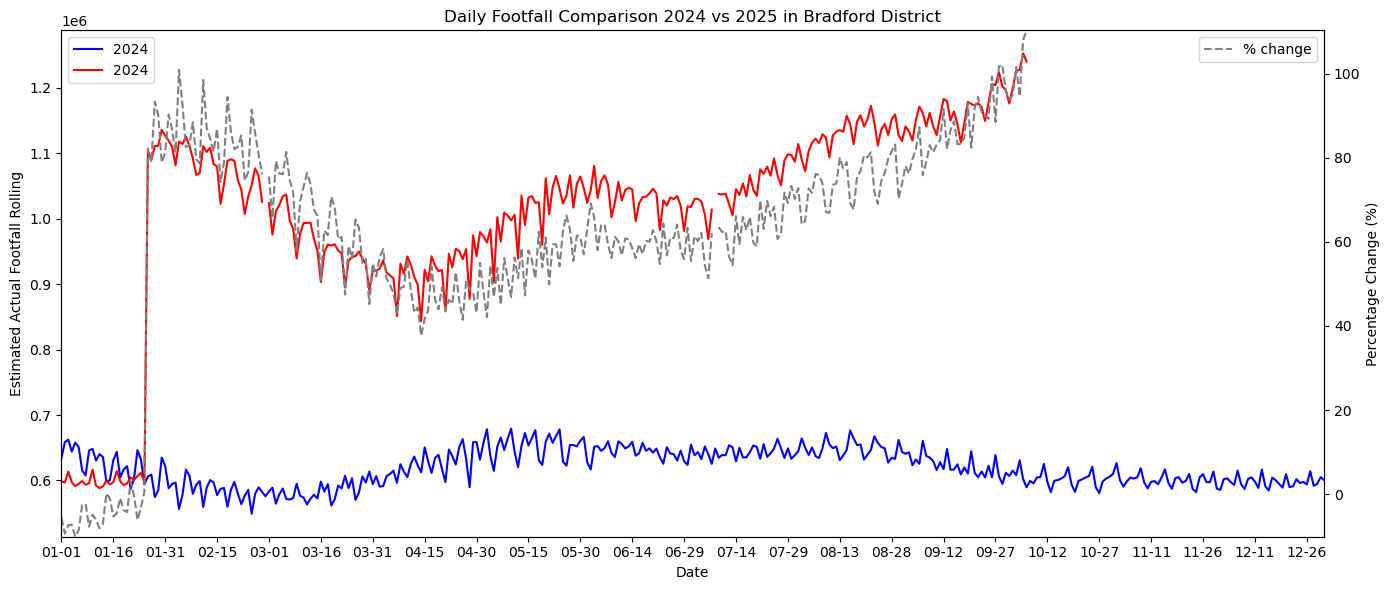

In [319]:
#Plot line plot of 2024, 2025 and percent change over time

fig, ax1 = plt.subplots(figsize=(14,6))

#Plot 2024 and 2025 footfall counts
ax1.plot(pivot.index, pivot[2024], label='2024', color='blue')
ax1.plot(pivot.index, pivot[2025], label='2024', color= 'red')
ax1.set_xlabel('Date')
ax1.set_ylabel('Estimated Actual Footfall Rolling')
ax1.set_xticks(pivot.index[::15]) #have ticks every 15 days
ax1.legend(loc='upper left')
ax1.margins(x=0)

#Plot percentage change between the 2 years
ax2 = ax1.twinx() #same x axis
ax2.plot(pivot.index, pivot['pct_change'], label='% change', color= 'grey', linestyle= '--')
ax2.set_ylabel('Percentage Change (%)')
ax2.legend(loc='upper right')
ax2.margins(y=0)

plt.title('Daily Footfall Comparison 2024 vs 2025 in Bradford District')
plt.tight_layout()
plt.show

To conduct the machine learning model, only the footfall for the 'Met Office - Bradford' area is kept.

In [321]:
footfall_Met.head()

,datestamp,centre_name,estimated_actual_footfall,estimated_actual_footfall_rolling,year,month,weekday,week_of_year,Sin_weekday,Cos_weekday,Sin_week_of_year,Cos_week_of_year,Sin_month,Cos_month,geometry,month_day
2497,2019-01-01,Met Office - Bradford,530996.0,571980,2019,1,1,1,8.660254e-01,0.5,0.118273,0.992981,0.5,0.866025,"POLYGON ((-1.88042 53.96298, -1.87951 53.96284...",01-01
2498,2019-01-02,Met Office - Bradford,568621.0,572734,2019,1,2,1,8.660254e-01,-0.5,0.118273,0.992981,0.5,0.866025,"POLYGON ((-1.88042 53.96298, -1.87951 53.96284...",01-02
2499,2019-01-03,Met Office - Bradford,606939.0,538667,2019,1,3,1,1.224647e-16,-1.0,0.118273,0.992981,0.5,0.866025,"POLYGON ((-1.88042 53.96298, -1.87951 53.96284...",01-03
2500,2019-01-04,Met Office - Bradford,508695.0,532787,2019,1,4,1,-8.660254e-01,-0.5,0.118273,0.992981,0.5,0.866025,"POLYGON ((-1.88042 53.96298, -1.87951 53.96284...",01-04
2501,2019-01-05,Met Office - Bradford,468546.0,507700,2019,1,5,1,-8.660254e-01,0.5,0.118273,0.992981,0.5,0.866025,"POLYGON ((-1.88042 53.96298, -1.87951 53.96284...",01-05


In [322]:
#Drop columns unneeded for analysis
footfall_Met = footfall_Met.drop(columns=['centre_name', 'geometry', 'month_day'])
footfall_Met.head()

,datestamp,estimated_actual_footfall,estimated_actual_footfall_rolling,year,month,weekday,week_of_year,Sin_weekday,Cos_weekday,Sin_week_of_year,Cos_week_of_year,Sin_month,Cos_month
2497,2019-01-01,530996.0,571980,2019,1,1,1,8.660254e-01,0.5,0.118273,0.992981,0.5,0.866025
2498,2019-01-02,568621.0,572734,2019,1,2,1,8.660254e-01,-0.5,0.118273,0.992981,0.5,0.866025
2499,2019-01-03,606939.0,538667,2019,1,3,1,1.224647e-16,-1.0,0.118273,0.992981,0.5,0.866025
2500,2019-01-04,508695.0,532787,2019,1,4,1,-8.660254e-01,-0.5,0.118273,0.992981,0.5,0.866025
2501,2019-01-05,468546.0,507700,2019,1,5,1,-8.660254e-01,0.5,0.118273,0.992981,0.5,0.866025


In [323]:
#Save the cleaned dataset
footfall_Met.to_csv('footfall_Met')